In [1]:
%reset -f
%reload_ext autoreload
%autoreload 2

In [2]:
import os,sys
current_path = os.getcwd()
sys.path.append("/home/zhuchen/poc/scorecard") 

In [3]:
name = current_path.split('/')[-1].split('_')
data = name[0]
cust = name[1]

In [4]:
print(name)

['deltaV1', 'all']


In [5]:
FILE_PATH = f'/home/zhuchen/poc/02-xyf/{data}_{cust}/file/'
DATA_PATH = f'/home/zhuchen/poc/02-xyf/{data}_{cust}/data/'
TMP_PATH  = f'/home/zhuchen/poc/02-xyf/{data}_{cust}/tmp/'
DATA_OR_PATH = '/home/zhuchen/poc/02-xyf/data_or/'

In [6]:
import zipfile
import gc
import pandas as pd 
import numpy as np  
import math  
import matplotlib.pyplot as plt
import copy
import seaborn as sns
# from pylab import mpl
# mpl.rcParams['font.sans-serif'] = ['SimHei']
# mpl.rcParams['axes.unicode_minus'] = False  

isExists=os.path.exists(FILE_PATH)
if not isExists:
    os.makedirs(FILE_PATH) 
    
isExists=os.path.exists(DATA_PATH)
if not isExists:
    os.makedirs(DATA_PATH) 

import warnings
warnings.filterwarnings("ignore")

In [7]:
data_all = pd.read_parquet(DATA_PATH + 'data_model.parquet')

In [8]:
data_all['target'].value_counts()

train    803775
valid    344476
oot      129491
Name: target, dtype: int64

In [9]:
ex_lst = ['mobile','backPointTime','qudao3_act','label',
 'weight',
 'target',
 'month_time',
 'day_time',
 'week_time',]
ft_lst = [i for i in data_all.columns if i not in ex_lst]
len(ft_lst)

print('num_feature: ', len(ft_lst))
print('data_shape: ', data_all.shape)

num_feature:  2000
data_shape:  (1277742, 2009)


## 特征筛选

#### round 2 iv psi

In [10]:
key_value = pd.read_excel(FILE_PATH + 'key_value.xlsx')

In [11]:
# ft_lst = pd.read_csv(DATA_PATH + 'ft_lst.csv')['var_names'].to_list()

In [12]:
# key_value = key_value[key_value['var_names'].isin(ftr1_keep)]
key_value = key_value[key_value['var_names'].isin(ft_lst)]

key_value.sort_values(by='iv_bin_train',ascending=False)

,Unnamed: 0.1,Unnamed: 0,var_names,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,psi_to_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
1724,24,24,TZ_1381_m12,0.0,0.038564,0.036497,0.008511,0.032865,1.108571e-06,0.015145,...,-1.0,-1.0,-1.0,-1.0,2.0,8.0,20.0,25.000000,38.000000,56.000000
1927,227,227,TZ_1381_m24,0.0,0.037503,0.038238,0.011769,0.032295,1.339798e-05,0.009230,...,-1.0,-1.0,-1.0,0.0,4.0,15.0,23.0,32.000000,39.000000,56.000000
1906,206,206,TZ_1381_m18,0.0,0.037476,0.036241,0.012913,0.032099,1.957952e-05,0.015288,...,-1.0,-1.0,-1.0,0.0,3.0,12.0,22.0,29.000000,38.000000,56.000000
1902,202,202,TZ_0264_m24,0.0,0.036290,0.035740,0.008300,0.029613,3.680588e-06,0.032093,...,-1.0,1.0,4.0,10.0,20.0,23.0,33.0,38.000000,44.000000,56.000000
1904,204,204,TZ_0264_m12,0.0,0.035987,0.036751,0.011556,0.029685,1.010345e-05,0.042098,...,-1.0,0.0,2.0,5.0,11.0,20.0,24.0,31.000000,39.000000,56.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1584,84,84,TZ_0455_m3,0.0,0.003567,0.004010,0.003825,0.003395,1.111656e-07,0.008236,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,3.000000,17.000000,56.000000
341,41,41,TZ_0288_m4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000,2.000000,18.000000
340,40,40,TZ_0290_m4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000,2.000000,4.000000
474,174,174,TZ_0143_m3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,110.333336


In [13]:
key_value.sort_values(by='iv_bin_train',ascending=False).head()

,Unnamed: 0.1,Unnamed: 0,var_names,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,psi_to_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
1724,24,24,TZ_1381_m12,0.0,0.038564,0.036497,0.008511,0.032865,0.000001,0.015145,...,-1.0,-1.0,-1.0,-1.0,2.0,8.0,20.0,25.0,38.0,56.0
1927,227,227,TZ_1381_m24,0.0,0.037503,0.038238,0.011769,0.032295,0.000013,0.009230,...,-1.0,-1.0,-1.0,0.0,4.0,15.0,23.0,32.0,39.0,56.0
1906,206,206,TZ_1381_m18,0.0,0.037476,0.036241,0.012913,0.032099,0.000020,0.015288,...,-1.0,-1.0,-1.0,0.0,3.0,12.0,22.0,29.0,38.0,56.0
1902,202,202,TZ_0264_m24,0.0,0.036290,0.035740,0.008300,0.029613,0.000004,0.032093,...,-1.0,1.0,4.0,10.0,20.0,23.0,33.0,38.0,44.0,56.0
1904,204,204,TZ_0264_m12,0.0,0.035987,0.036751,0.011556,0.029685,0.000010,0.042098,...,-1.0,0.0,2.0,5.0,11.0,20.0,24.0,31.0,39.0,56.0


In [14]:
key_value['iv_bin_total']

0       0.007654
1       0.007193
2       0.007120
3       0.008800
4       0.006787
          ...   
1995    0.019250
1996    0.019537
1997    0.019368
1998    0.019564
1999    0.014415
Name: iv_bin_total, Length: 2000, dtype: float64

In [15]:
key_value['dif'] = key_value['iv_bin_train'] / key_value['iv_bin_oot']
key_value['dif2'] = key_value['iv_bin_train'] / key_value['iv_bin_valid']
key_value[['psi_tvo_bin', 'dif','dif2']].describe()

,psi_tvo_bin,dif,dif2
count,2000.000000,1.996000e+03,1996.000000
mean,0.017429,4.064170e+03,1.009302
std,0.020033,1.591011e+05,0.183769
min,0.000000,9.323627e-01,0.462317
25%,0.004779,3.370544e+00,0.933533
50%,0.011009,1.322236e+01,0.990439
75%,0.022522,3.931557e+01,1.061292
max,0.154005,7.107259e+06,3.020841


In [ ]:
iv_keep = key_value
iv_keep = key_value[key_value['psi_tvo_bin'] < 0.1]
# iv_keep = iv_keep[iv_keep['dif'] > 0.2]
iv_keep = iv_keep[iv_keep['dif'] < 1.5]
# iv_keep = iv_keep[iv_keep['dif2'] > 0.2]
# iv_keep = iv_keep[iv_keep['dif2'] < 10]
iv_keep = iv_keep[iv_keep['iv_bin_train'] > 0.001]
# iv_keep = iv_keep[iv_keep['iv_bin_valid'] > 0.08]
iv_keep = iv_keep[iv_keep['iv_bin_oot'] > 0.001]
iv_keep.sort_values('iv_bin_total', ascending=False, inplace=True)
# iv_keep = iv_keep['var_names'].to_list()
iv_keep = iv_keep['var_names'].iloc[0:1100].to_list()
len(iv_keep)

26

In [50]:
pd.DataFrame({'var_names': iv_keep}).to_csv(FILE_PATH + 'r2_iv_psi_keep.csv')

In [51]:
import gc 
gc.collect()

2130

#### round 1 missing std freq

In [52]:
# train = data_all[data_all['target']=='train']
# valid = data_all[data_all['target']=='valid']
# oot = data_all[data_all['target']=='oot']

In [53]:
import gc 
gc.collect()

0

In [54]:
from FeatureEngineering.Selection.Filter import Filter
filter_ = Filter(data_all[iv_keep+ex_lst], 'label', ex_lst, FILE_PATH)

In [55]:
r1_keep = filter_.round_1({'missing': 0.95, 'std':0, 'freq': 0.95})

missing   num_drop: 0,   num_keep: 76 
std   num_drop: 0,   num_keep: 76 
freq   num_drop: 0,   num_keep: 76 


In [56]:
ftr1_keep = r1_keep['freq'].keep_lst
print(len(ftr1_keep))

76


In [57]:
# ftr1_keep = ft_lst

In [58]:
pd.DataFrame({'var_names': ftr1_keep}).to_csv(FILE_PATH + 'r1_msf_keep.csv')

In [59]:
import gc 
gc.collect()

0

#### round 3 feature_importance

In [60]:
gc.collect()

0

In [61]:
ftr1_keep = pd.read_csv(FILE_PATH + 'r1_msf_keep.csv')['var_names'].to_list()
len(ftr1_keep)

76

In [62]:
len(ftr1_keep)

76

In [63]:
from FeatureEngineering.KeyValue import Importance
ipt_value = Importance.value(data_all[ftr1_keep + ex_lst].fillna(-999), 'train', 'valid', dep='label', exclude=ex_lst, model_switch=[0, 1, 0, 0, 0])
ipt_value.sort_values(by='xgb_gain', ascending=False)

,var_names,xgb_gain,xgb_total_gain,xgb_weight,xgb_total_cover,xgb_cover,xgb_shap_value
50,TZ_0276_m24,0.072096,0.022975,0.008961,0.017992,0.047385,0.008173
55,TZ_0265_m12,0.065577,0.041794,0.017921,0.022207,0.029243,0.018672
46,TZ_0277_m24,0.062151,0.039611,0.017921,0.026119,0.034394,0.015279
0,TZ_0265_m15,0.061530,0.074509,0.034050,0.059501,0.041237,0.039096
10,TZ_0265_m18,0.058493,0.119294,0.057348,0.078585,0.032338,0.059192
...,...,...,...,...,...,...,...
32,TZ_0081_w4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40,TZ_0278_m15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
56,TZ_0087_m18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
35,TZ_0272_w4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [64]:
ipt_keep = ipt_value[ipt_value['xgb_gain'] > 0.00]['var_names'].to_list()
len(ipt_keep)

57

num_features:  57
XGBoost：
  datasets       auc  precision    recall        ks        f2        th  \
0    valid  0.563558   0.050282  0.830967  0.088630  0.202418  0.038261   
0    train  0.569646   0.051713  0.778703  0.095464  0.204295  0.040671   
0      oot  0.533520   0.055332  0.868872  0.053704  0.220495  0.034830   

      ratio   count  
0  0.760346  344476  
0  0.692838  803775  
0  0.828606  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    valid  0.563558  0.088630   0.050282  0.830967  0.202418  0.038261   
0    train  0.569646  0.095464   0.051713  0.778703  0.204295  0.040671   
0      oot  0.533520  0.053704   0.055332  0.868872  0.220495  0.034830   

      ratio   count  
0  0.760346  344476  
0  0.692838  803775  
0  0.828606  129491  


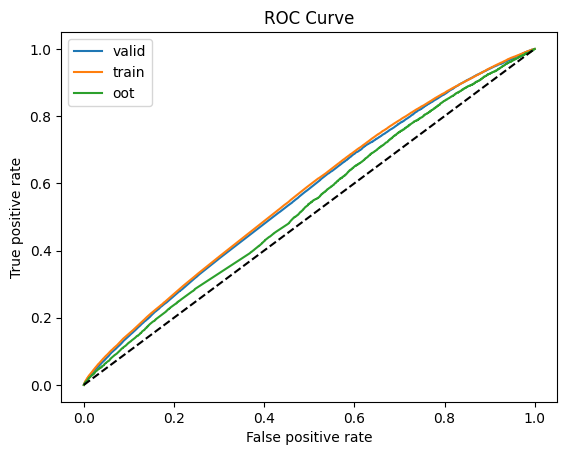

In [65]:
from Model.train import bi_train
res =  bi_train(data_all[ipt_keep + ex_lst].fillna(-999), dep='label', exclude=ex_lst, model_switch=[0, 1, 0, 0])

In [66]:
ipt_value[ipt_value['xgb_gain'] > 0.0][['var_names']].to_csv(FILE_PATH + 'r3_ipt_keep.csv')

In [67]:
data_all[ipt_keep + ex_lst].fillna(-999).to_csv(DATA_PATH + 'data_ft_2.csv', index=False, encoding='utf-8-sig')

In [68]:
%reset -f